# Import Modules and Functions

In [2]:
from LC_utility import *

In [3]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [5]:
## reference tables
table_a57 = pd.read_csv('LC_tables/data/LCref_a57_i.csv')
table_a54 = pd.read_csv('LC_tables/data/LCref_a54_i.csv')

## segment 1
lc_data1 = pd.read_csv('LC_tables/data/LCtable1_i.csv')

## segment 2
lc_data2 = pd.read_csv('LC_tables/data/LCtable2_i.csv')

## segment 3
lc_data3 = pd.read_csv('LC_tables/data/LCtable3_i.csv')

## segment 4
lc_data4 = pd.read_csv('LC_tables/data/LCtable4_i.csv')

In [6]:
### Some images need to be excluded due to quality
### Images from ccd 54 have bad bands (mainly filter i is affected)

## filter g
badims_a54g = pd.read_csv('txt_files/ec0915a54g_badims.txt', header=None)[0]
bad_expnums_a54g = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54g]

## filter r
bad_expnums_a54r = None

## filter i
badims_a54i = pd.read_csv('txt_files/ec0915a54i_badims.txt', header=None)[0]
bad_expnums_a54i = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54i]
# bad_expnums_a54i = None

## filter z
bad_expnums_a54z = None

# Combine LCs

### Fitting Process for Each Segment

In [9]:
### Define uncertainty/error cuts

## segment 1
n_sigs1 = [3.0, 1.0]                  # n-sigma cuts based on micro-Jyas2 and its error
mJyas2_lms1 = None                    # upperlimits on micro-Jyas2 and its error

## segment 2
n_sigs2 = None
mJyas2_lms2 = [20.0, 1.0]

## segment 3
n_sigs3 = None
mJyas2_lms3 = [5.0, 1.0]

## segment 4
n_sigs4 = None
mJyas2_lms4 = [5.0, 1.0]

In [10]:
### Fit LCs to a template
### 1st iteration --> template is an individual LC

## segment 1
templ_ID1 = 2
fit_parms1 = fit_LCs(lc_data1, templ_ID=templ_ID1, n_sigmas=n_sigs1, mJyas2_lms=mJyas2_lms1)

## segment 2
templ_ID2 = 34
fit_parms2 = fit_LCs(lc_data2, templ_ID=templ_ID2, n_sigmas=n_sigs2, mJyas2_lms=mJyas2_lms2, bad_expnums=bad_expnums_a54i)

## segment 3
    # specify range where there is a local maximimum (peak)
templ_ID3 = 90
fit_parms3 = fit_LCs(lc_data3, templ_ID=templ_ID3, n_sigmas=n_sigs3, mJyas2_lms=mJyas2_lms3, bad_expnums=bad_expnums_a54i, t_range=[57000,57900])

## segment 4
    # no tshift as the tail end seems aligned -- also no specific feature to pinpoint
templ_ID4 = 0
fit_parms4 = fit_LCs(lc_data4, templ_ID=templ_ID4, n_sigmas=n_sigs4, mJyas2_lms=mJyas2_lms4, bad_expnums=bad_expnums_a54i, tshift_d=0.)

In [11]:
### Save tshifts for other filters

iparms1 = pd.DataFrame(fit_parms1)
iparms2 = pd.DataFrame(fit_parms2)
iparms3 = pd.DataFrame(fit_parms3)
iparms4 = pd.DataFrame(fit_parms4)


iparms1.to_csv('LC_tables/fit_params/fparams_i1.csv', index=False)
iparms2.to_csv('LC_tables/fit_params/fparams_i2.csv', index=False)
iparms3.to_csv('LC_tables/fit_params/fparams_i3.csv', index=False)
iparms4.to_csv('LC_tables/fit_params/fparams_i4.csv', index=False)

In [12]:
### Create data frame of aligned LCs

## segment 1
comb1 = get_alignedLCs(lc_data1, fit_parms1, n_sigmas=n_sigs1, mJyas2_lms=mJyas2_lms1)

## segment 2
comb2 = get_alignedLCs(lc_data2, fit_parms2, n_sigmas=n_sigs2, mJyas2_lms=mJyas2_lms2, bad_expnums=bad_expnums_a54i)

## segment 3
comb3 = get_alignedLCs(lc_data3, fit_parms3, n_sigmas=n_sigs3, mJyas2_lms=mJyas2_lms3, bad_expnums=bad_expnums_a54i)

## segment 4
comb4 = get_alignedLCs(lc_data4, fit_parms4, n_sigmas=n_sigs4, mJyas2_lms=mJyas2_lms4, bad_expnums=bad_expnums_a54i)

In [13]:
### Create combined LC
### Use sigmacutloop function in pdastro to calculate mean

## segment 1
t_means1, f_means1, f_merrs1, o_params1 = get_combinedLC(comb1, bn_sz=30)
    # o_params --> other parameters --> stdev, stdev_err, chi2, ix_good, ix_bad
    # w_inds --> indices of data points used for combination after sigma-cut
w_inds1 = [i for ix in o_params1[3] for i in ix]

## segment 2
t_means2, f_means2, f_merrs2, o_params2 = get_combinedLC(comb2, bn_sz=30)
w_inds2 = [i for ix in o_params2[3] for i in ix]

## segment 3
t_means3, f_means3, f_merrs3, o_params3 = get_combinedLC(comb3, bn_sz=30)
w_inds3 = [i for ix in o_params3[3] for i in ix]

## segment 4
t_means4, f_means4, f_merrs4, o_params4 = get_combinedLC(comb4, bn_sz=30)
w_inds4 = [i for ix in o_params4[3] for i in ix]

### See/Check Fitting Process

In [15]:
### See individual LCs

# ## 4 segments (labelled 1-4)
# df = lc_data1
# # df = lc_data2

# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# plot_lcs(df, n_sigmas=n_s, mJyas2_lms=mJy_lm)
# plot_lcs(df, n_sigmas=n_s, mJyas2_lms=mJy_lm, plt_xl=60400)

In [16]:
### See Fitting Process

# df = lc_data1
# # df = lc_data2

# fit_ps = fit_parms1
# t_ID = templ_ID1
# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# plot_LCfits(df,fit_ps, templ_ID=t_ID, n_sigmas=n_s, mJyas2_lms=mJy_lm)

In [17]:
### See aligned LCs

# df = lc_data1
# # df = lc_data2

# fit_ps = fit_parms1
# t_ID = templ_ID1
# n_s = n_sigs1
# mJy_lm = mJyas2_lms1

# for i in fit_ps[0]:
#     df_inds = get_LCinds(df, lc_ID=i, n_sigmas=n_s, mJyas2_lms=mJy_lm)
#     plt.errorbar(df.loc[df_inds,'new_mjd'], df.loc[df_inds,'new_mJyas2'], yerr=df.loc[df_inds,'new_mJyas2_err'], fmt='.-', ecolor='black')

In [18]:
### See combined LC

# comb_d = comb1
# winds = w_inds1

# t_mns = tmns1
# f_mns = fmns1
# # f_mers = fmers1

# plt.errorbar(comb_d.t.loc[winds,'mjd'], comb_d.t.loc[winds,'mJyas2'], fmt='.-', color='blue', alpha=0.25)
# plt.axhline(y=0, linestyle='--', color='black')
# plt.errorbar(t_mns, f_mns, fmt='--o', ecolor='black', color='orange') #,yerr=f_mers
# plt.xlabel('MJD')
# plt.ylabel('$\mu$Jy/as$^2$')
# plt.show()

# Model LC

### Combine Segments

In [21]:
### Fit segments with overlap

tshiftm21, am21, bm21 = get_tshift_scale_offset(t_means2, f_means2, f_merrs2, t_means1, f_means1, f_merrs1)

# define peaks to use in fitting (see LC)
t_pm23 = [59310, 57530]
tshiftm23, am23, bm23 = get_tshift_scale_offset(t_means2, f_means2, f_merrs2, t_means3, f_means3, f_merrs3, t_peaks=t_pm23)

# t_pm24 = [60700, t_means4[0]]
# tshiftm24, am24, bm24 = get_tshift_scale_offset(t_means2, f_means2, f_merrs2, t_means4, f_means4, f_merrs4, t_peaks=t_pm24)


# # Fit segment 4 to already fitted segment 3
# m_t3 = t_means3-tshiftm23
# m_f3 = am23*f_means3+bm23
# m_ferr3 = am23*f_merrs3

# tshiftm34, am34, bm34 = get_tshift_scale_offset(m_t3, m_f3, m_ferr3, t_means4, f_means4, f_merrs4, tshift_d=-4550)

## From previous run of fits that included bad images -- increases overlap
# tshiftm34 = -4550.79
# am34 = 2.72
# bm34 = -44.33

tshiftm34 = -4500
am34 = 2.74
bm34 = -44.23

In [22]:
# print(tshiftm21,am21,bm21)
# print(tshiftm23,am23,bm23)
# print(tshiftm34,am34,bm34)

In [23]:
### Combine Segments
    ## Combine model data

offsetm = 65.5       # look at plot to decide

m_t1 = t_means1-tshiftm21
m_f1 = (am21*f_means1+bm21)+offsetm
m_ferr1 = am21*f_merrs1

m_t2 = t_means2
m_f2 = f_means2+offsetm
m_ferr2 = f_merrs2

m_t3 = t_means3-tshiftm23
m_f3 = (am23*f_means3+bm23)+offsetm
m_ferr3 = am23*f_merrs3

m_t4 = t_means4-tshiftm34
m_f4 = (am34*f_means4+bm34)+offsetm
m_ferr4 = am34*f_merrs4

In [24]:
### These t-shifts will be used for the other filters

print([tshiftm21, 0, tshiftm23, tshiftm34])

[2875.363251889241, 0, -1780, -4500]


In [25]:
### Combine Segments
    ## Combine LC data

fin_t1 = comb1.t.loc[w_inds1,'mjd'].values-tshiftm21
fin_f1 = (am21*comb1.t.loc[w_inds1,'mJyas2'].values+bm21)+offsetm
fin_ferr1 = am21*comb1.t.loc[w_inds1,'mJyas2_err'].values

fin_t2 = comb2.t.loc[w_inds2,'mjd'].values
fin_f2 = comb2.t.loc[w_inds2,'mJyas2'].values+offsetm
fin_ferr2 = comb2.t.loc[w_inds2,'mJyas2_err'].values

fin_t3 = comb3.t.loc[w_inds3,'mjd'].values-tshiftm23
fin_f3 = (am23*comb3.t.loc[w_inds3,'mJyas2'].values+bm23)+offsetm
fin_ferr3 = am23*comb3.t.loc[w_inds3,'mJyas2_err'].values

fin_t4 = comb4.t.loc[w_inds4,'mjd'].values-tshiftm34
fin_f4 = (am34*comb4.t.loc[w_inds4,'mJyas2'].values+bm34)+offsetm
fin_ferr4 = am34*comb4.t.loc[w_inds4,'mJyas2_err'].values


tls_m = np.concatenate([fin_t1, fin_t2, fin_t3, fin_t4])
fls_m = np.concatenate([fin_f1, fin_f2, fin_f3, fin_f4])
ferrls_m = np.concatenate([fin_ferr1, fin_ferr2, fin_ferr3, fin_ferr4])

ord_inds_m = tls_m.argsort()
tls_m = tls_m[ord_inds_m]
fls_m = fls_m[ord_inds_m]
ferrls_m = ferrls_m[ord_inds_m]

comb_m_data = {'mjd': tls_m, 'mJyas2': fls_m, 'mJyas2_err': ferrls_m}
comb_m = pdastrostatsclass()
comb_m.t = comb_m.t.assign(**comb_m_data)

## Save table for bookkeeping purposes
comb_m.t.to_csv('LC_tables/models/iLC_data1.csv', index=False)

In [26]:
### Create the model (LC_0)

t_model, f_model, ferr_model, o_params_m = get_combinedLC(comb_m, bn_sz=30)
w_inds_m = [i for bn in o_params_m[3] for i in bn]


lc_model = {'mjd':t_model, 'mJyas2':f_model, 'mJyas2_err':ferr_model}
lc_model_d = pd.DataFrame(lc_model)

lc_model_d.to_csv('LC_tables/models/iLC_m1.csv', index=False)

### See Model Fitting

In [28]:
### Individual Segements

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,8], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD (days)')

# axs[0].errorbar(t_means1, f_means1, yerr=f_merrs1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# axs[1].errorbar(t_means2, f_means2, yerr=f_merrs2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# axs[2].errorbar(t_means3, f_means3, yerr=f_merrs3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# axs[3].errorbar(t_means4, f_means4, yerr=f_merrs4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
#     ax.legend(fontsize = 14)

# # pl_fig.savefig('../figures/display/EtaCar_PiecesM.png', bbox_inches = 'tight', dpi=100)

In [29]:
### Fitting segment 3 and 4
### Run with bad images so there is an overlap -- will need to address this later
### Good agreement, but then model tail doesn't go low enough (below the beginning part)

# m_t3 = t_means3-tshiftm23
# m_f3 = (f_means3*am23)+bm23
# m_ferr3 = f_merrs3

# t_pm34 = [60842, tmns4[0]]
# t_pm34 = [60876, tmns4[0]]
# t_pm34 = [60892, tmns4[0]]
# tshiftm34, am34, bm34 = get_tshift_scale_offset(m_t3, m_f3, m_ferr3, t_means4, f_means4, f_merrs4, t_peaks=t_pm34)

In [30]:
### Testing different tshifts between segment 3 and 4
# # t_pm34 = [60630, t_means4[0]]
# # t_pm34 = [60829, t_means4[0]]
# for i in np.linspace(60500,61300,50):
#     t_pm34 = [i, t_means4[0]]
#     tshiftm34, am34, bm34 = get_tshift_scale_offset(m_t3, m_f3, m_ferr3, t_means4, f_means4, f_merrs4, t_peaks=t_pm34)
#     print(i, tshiftm34, [am34,bm34])
#     m_t4 = t_means4-tshiftm34
#     m_f4 = am34*f_means4+bm34
#     m_ferr4 = am34*f_merrs4
    
#     plt.errorbar(m_t3, m_f3, fmt='--o', ecolor='black', color='red', label='Section 3')
#     plt.errorbar(m_t4, m_f4, fmt='--o', ecolor='black', color='orange', label='Section 4', alpha=0.5)
#     plt.show()

In [31]:
### See Connected Segments

# fig, ax = plt.subplots(dpi = 100, figsize = [8,5])
# ax.minorticks_on()
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
# ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# ax.set_xlabel('MJD (days)', fontsize = 14)
# ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
# ax.ticklabel_format(axis='both', style='plain')


# ax.errorbar(m_t1, m_f1, yerr=m_ferr1, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')
# ax.errorbar(m_t2, m_f2, yerr=m_ferr2, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')
# ax.errorbar(m_t3, m_f3, yerr=m_ferr3, fmt='--o', ecolor='black', color='red', label='Loc 3')
# ax.errorbar(m_t4, m_f4, yerr=m_ferr4, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# ax.axhline(y=0, ls='--', color='k')

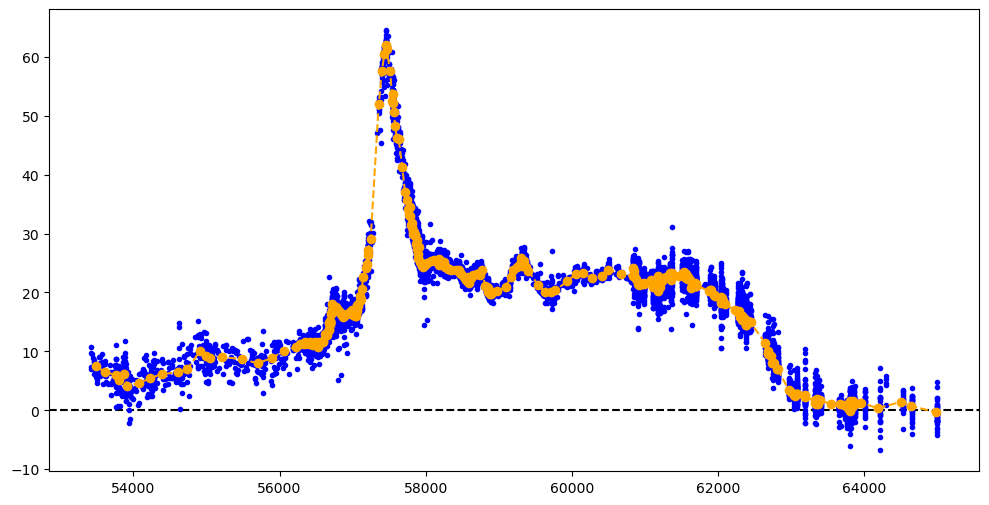

In [32]:
### Plot Model
plt.subplots(dpi = 100, figsize = [12,6])
plt.errorbar(comb_m.t.loc[w_inds_m,'mjd'], comb_m.t.loc[w_inds_m,'mJyas2'], fmt='.', ecolor='black', color='blue')
plt.errorbar(t_model, f_model, fmt='--o', ecolor='black', color='orange')
plt.axhline(y=0, linestyle='--', color='black')